# Failure Analysis: How a Rolling Mean Killed a Signal
### Null Simulation Framework for Mean-Reversion Models · Premier League 2015–2025

## Executive Summary

This notebook contains the most important result in the project.

Notebooks 01–06 built a four-layer quantitative pipeline that produced
results compelling enough to pass every standard validation test:

| Metric | Value |
|---|---|
| Strong signal reversion rate | 88–90% |
| Spearman ρ (\|z\| vs reversion) | 0.558 |
| Permutation p-value | < 0.0001 |
| Benjamini-Hochberg correction | Passed at all 5 thresholds |
| Walk-forward validation | Corrected (Viterbi smoother replaced with forward algorithm) |
| Trading simulation return | +22.7% over 7 seasons |

**Every number is correct. Every test passed. The signal does not exist.**

The 88–90% reversion rate is entirely generated by the 5-match rolling
mean smoothing operator applied to the xG-goals spread in Notebook 01.
A pure iid white noise through the identical pipeline produces 91.2%
reversion. The real data produces 89.1%. The real data is on the
wrong side of the null.

This is not a subtle modelling error. It is a pipeline-level
contamination that standard validation tools — permutation tests,
Spearman correlations, walk-forward validation — cannot detect because
they all operate within the artefactual structure rather than testing
against it.

---

## TL;DR
```
Rolling mean null (iid white noise):    91.2%    pipeline generates this
Rolling mean real data:             89.1%    real data below null
Raw spread independent null:        79.5%    null misspecified
Raw spread real data:               86.4%    looks like +6.9pp signal
Raw spread structured null:         87.9%    correct null
Gap (real vs structured null):      −1.5pp   signal dead
```

Season-to-season xG spread persistence (Pearson r = 0.306, p = 0.0001) 
is the only statistically significant structure that survives all null 
testing. It reflects the fact that teams with stable tactical identities 
— direct play, high press, low-block — tend to maintain consistent 
relationships between their xG and goals across seasons. This is a 
real and expected finding, not a novel one. It is not exploitable 
through a match-level trading signal.


---

## Introduction

### What This Notebook Does

This notebook runs four diagnostic tests that should have been run
before any signal pipeline was built. They are presented here in the
correct sequence — from cheapest to most definitive — with commentary
on when and how each would have stopped the project.

The tests are not destructive of the earlier work. Notebooks 01–06
are preserved as forensic evidence of how convincing the false positive
was at every stage. The pipeline is correct. The methodology is sound.
The smoothing step in Notebook 01 — a single line of code — invalidated
every downstream result by generating artefactual mean-reversion from
a process that has none.

### Why Standard Tests Missed It

The permutation test used in Notebook 05A shuffles z-score bucket
labels within the smoothed data. This tests whether label assignment
matters — it does not test whether the smoothing creates the pattern.
A permutation p-value of 0.0001 on a smoothed series is consistent
with either a genuine signal or a smoothing artefact. The two cannot
be distinguished without a pipeline-level null simulation.

This is a known hazard in quantitative modelling. In energy markets,
analysts apply moving averages to noisy price series before fitting
O-U models and discover mean-reversion that is the filter's impulse
response. The mechanism is identical. The football dataset made it
visible because the ground truth — independent xG and goals
observations at match level — is available for comparison.

### The One Test That Caught It

The pipeline null simulation asks a fundamentally different question
to every other test in the project:

> "If I apply the identical pipeline — including the rolling mean —
> to data generated by a process with no genuine mean reversion, what
> signal does it produce?"

The answer is 91.2% strong signal reversion. The real data produces
89.1%. The pipeline is the signal.

### What Survives

One finding survives all null testing: season-to-season xG spread
persistence (r = 0.306, p = 0.0001). This is measured directly on
season means, not through the reversion criterion, so it is not
affected by the smoothing artefact. It is real structure — teams
with stable tactical identities and squad compositions tend to
maintain their xG spread characteristics across seasons. It is not
exploitable through a match-level signal at the timescales tested here.

### The Reusable Output

The four-step diagnostic framework developed in this notebook is the
genuine contribution of the project. It applies to any mean-reversion
model in any domain where smoothing is applied before parameter
estimation — energy spreads, credit spreads, commodity basis, or any
other mean-reverting financial series.

Run these four checks before building any signal pipeline:

| Step | Check | Cost | Catches |
|---|---|---|---|
| 1 | Raw half-life vs observation interval | Minutes | Process has no inter-period memory |
| 2 | Posterior predictive simulation | Hours | Model describes smoothing operator, not data |
| 3 | Pipeline null simulation | Hours | Pipeline generates the signal |
| 4 | Structured null simulation | Hours | Variance misspecification in null |

If any step fails, stop. Do not proceed to signal validation.

### Structure of This Notebook
```
Cell 1  — Imports and setup
Cell 2  — Step 1: Parameter plausibility check (raw half-life)
Cell 3  — Step 2: Posterior predictive simulation
Cell 4  — Figure 1: PPS diagnostic plot
Cell 5  — Step 3: Pipeline null simulation
Cell 6  — Step 4: Structured null simulation
Cell 7  — Figure 2: Complete null simulation summary
Cell 8  — Season-level persistence
Cell 9  — Figure 3: Season persistence scatter
          Findings and Summary
```

---

In [16]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Imports and setup
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import binomtest
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
FIG_DIR      = PROJECT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
AMBER = '#C97A20'
RED   = '#A93226'
GREEN = '#1E8449'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# Simulation parameters — match real dataset structure
N_TEAMS   = 20
N_MATCHES = 380
WINDOW    = 5     # rolling mean window — identical to pipeline

print("✓ Setup complete")
print(f"  Data directory:    {DATA_DIR}")
print(f"  Figures directory: {FIG_DIR}")

✓ Setup complete
  Data directory:    /home/ndrew/xG-spread-model/data
  Figures directory: /home/ndrew/xG-spread-model/figures


---

## Notebook 07 — Null Simulation: Testing the Mean-Reversion Hypothesis

### Rolling Mean Artefacts in Mean-Reversion Models · Premier League 2015–2025

---

## Purpose

This notebook tests the foundational assumption of the entire project:
that the xG-goals spread in Premier League football shows genuine
mean reversion above what would be expected from a stationary process
with no genuine dynamics.

Notebooks 01–06 built a four-layer quantitative pipeline that produced
compelling results: 88–90% strong signal reversion rates, Spearman
ρ = 0.558, permutation p < 0.0001, and a trading simulation returning
+22.7% over 7 seasons. Every standard validation test passed.

This notebook runs the tests that should have been run first.

---

## The Smoothing Artefact Hypothesis

A 5-match rolling mean applied to any stationary time series induces
autocorrelation. When O-U parameters are estimated on a smoothed
series, the fitted model describes the smoothing operator rather than
the underlying process. The resulting z-scores will show high reversion
rates even when the underlying data has no genuine mean-reversion
dynamics.

This is not a subtle effect. It is a well-documented statistical
property. The question is whether the pipeline's 88–90% reversion rate
reflects genuine football dynamics or the rolling mean's impulse
response.

**The correct test is not a permutation test on the smoothed data.**
Shuffling z-score labels within the smoothed series tests whether
label assignment matters — it does not test whether the smoothing
creates the pattern. The correct test is a null simulation that applies
the identical pipeline to data with no genuine mean reversion.

---

## The Four Diagnostic Steps

The checks below should have been run in this order before any signal
pipeline was built. They are presented here in the correct sequence,
with commentary on when and how each would have stopped the project.

---

In [17]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Step 1: Parameter plausibility check
# The raw spread half-life is the first and cheapest diagnostic.
# A half-life shorter than the observation interval means the
# process has no inter-period memory — smoothing will create
# artefactual persistence.
# ─────────────────────────────────────────────────────────────────

tm       = pd.read_csv(DATA_DIR / "pl_team_match_spread.csv",
                       parse_dates=['date'])
eligible = pd.read_csv(DATA_DIR / "eligible_teams.csv")
eligible_teams = eligible['team'].tolist()

raw_halflives      = []
rolling_halflives  = []

for team in eligible_teams:
    team_data = (tm[tm['team'] == team]
                 .sort_values('date')
                 .dropna(subset=['raw_spread', 'rolling_spread'])
                 .copy()
                 .reset_index(drop=True))

    for col, store in [('raw_spread',     raw_halflives),
                       ('rolling_spread', rolling_halflives)]:

        S     = team_data[col].values
        dS    = np.diff(S)
        S_lag = S[:-1]
        slope, intercept, *_ = stats.linregress(S_lag, dS)

        if slope >= 0:
            continue

        theta = -slope
        store.append(np.log(2) / theta)

print("── Step 1: Parameter plausibility ───────────────────────────")
print()
print("  Half-life (matches):")
print(f"  {'Spread':<20} {'Mean':>8} {'Median':>8} "
      f"{'Min':>8} {'Max':>8}")
print(f"  {'-'*20}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}")
print(f"  {'Raw spread':<20}  "
      f"{np.mean(raw_halflives):>8.2f}  "
      f"{np.median(raw_halflives):>8.2f}  "
      f"{np.min(raw_halflives):>8.2f}  "
      f"{np.max(raw_halflives):>8.2f}")
print(f"  {'Rolling spread':<20}  "
      f"{np.mean(rolling_halflives):>8.2f}  "
      f"{np.median(rolling_halflives):>8.2f}  "
      f"{np.min(rolling_halflives):>8.2f}  "
      f"{np.max(rolling_halflives):>8.2f}")
print()
print("  Observation interval: 1 match")
print()
if np.median(raw_halflives) < 1.0:
    print("  ✗ RED FLAG: Median raw half-life < 1 match.")
    print("    The raw spread has no inter-period memory.")
    print("    Smoothing will create artefactual persistence.")
    print("    This should have stopped the project here.")
else:
    print("  ✓ Raw half-life > 1 match — smoothing may be appropriate.")

── Step 1: Parameter plausibility ───────────────────────────

  Half-life (matches):
  Spread                   Mean   Median      Min      Max
  --------------------  --------  --------  --------  --------
  Raw spread                0.69      0.69      0.58      0.81
  Rolling spread            3.51      3.43      2.37      4.84

  Observation interval: 1 match

  ✗ RED FLAG: Median raw half-life < 1 match.
    The raw spread has no inter-period memory.
    Smoothing will create artefactual persistence.
    This should have stopped the project here.


---

### Step 2 — Posterior Predictive Simulation

The PPS asks: does the O-U model fitted to the rolling spread generate
data that is compatible with the raw spread? If the raw spread falls
outside the posterior predictive interval for autocorrelation,
variance, and half-life, the model is operating in a different physical
reality to the data it is supposed to describe.

This check would have caught the artefact at the model specification
stage — before any signal pipeline was built.

---

In [18]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Step 2: Posterior predictive simulation
# Fit O-U to rolling spread. Simulate from fitted parameters.
# Check whether raw spread is plausible under the fitted model.
# ─────────────────────────────────────────────────────────────────

# Use Arsenal as focus team — representative of the dataset
team_data = (tm[tm['team'] == 'Arsenal']
             .sort_values('date')
             .dropna(subset=['raw_spread', 'rolling_spread'])
             .copy()
             .reset_index(drop=True))

rolling = team_data['rolling_spread'].values
raw     = team_data['raw_spread'].values

# Fit O-U to rolling spread
S_r     = rolling
dS_r    = np.diff(S_r)
S_lag_r = S_r[:-1]
slope_r, intercept_r, *_ = stats.linregress(S_lag_r, dS_r)
theta_r    = -slope_r
mu_r       = -intercept_r / slope_r
sigma_r    = np.std(dS_r - (intercept_r + slope_r * S_lag_r))
sigma_eq_r = sigma_r / np.sqrt(2 * theta_r)

# Fit O-U to raw spread
S_rw     = raw
dS_rw    = np.diff(S_rw)
S_lag_rw = S_rw[:-1]
slope_rw, intercept_rw, *_ = stats.linregress(S_lag_rw, dS_rw)
theta_rw    = -slope_rw
mu_rw       = -intercept_rw / slope_rw
sigma_rw    = np.std(dS_rw - (intercept_rw + slope_rw * S_lag_rw))
sigma_eq_rw = sigma_rw / np.sqrt(2 * theta_rw)

print("── O-U parameters ───────────────────────────────────────────")
print(f"  {'Parameter':<25} {'Rolling spread':>16} {'Raw spread':>12}")
print(f"  {'-'*25}  {'-'*16}  {'-'*12}")
print(f"  {'theta':<25}  {theta_r:>16.4f}  {theta_rw:>12.4f}")
print(f"  {'mu':<25}  {mu_r:>16.4f}  {mu_rw:>12.4f}")
print(f"  {'sigma':<25}  {sigma_r:>16.4f}  {sigma_rw:>12.4f}")
print(f"  {'sigma_eq':<25}  {sigma_eq_r:>16.4f}  {sigma_eq_rw:>12.4f}")
print(f"  {'half-life (matches)':<25}  "
      f"{np.log(2)/theta_r:>16.2f}  "
      f"{np.log(2)/theta_rw:>12.2f}")

# PPS: simulate from rolling-spread parameters
np.random.seed(42)
N_SIM = 500
n     = len(rolling)
dt    = 1.0

sim_autocorr = []
sim_variance = []
sim_halflife = []

for _ in range(N_SIM):
    sim    = np.zeros(n)
    sim[0] = mu_r
    for t in range(1, n):
        sim[t] = (sim[t-1]
                  + theta_r * (mu_r - sim[t-1]) * dt
                  + sigma_r * np.sqrt(dt) * np.random.randn())

    sim_autocorr.append(pd.Series(sim).autocorr(lag=1))
    sim_variance.append(np.var(sim))

    dS_s    = np.diff(sim)
    S_lag_s = sim[:-1]
    sl, ic, *_ = stats.linregress(S_lag_s, dS_s)
    if sl < 0:
        sim_halflife.append(np.log(2) / (-sl))

# Real diagnostics
real_ac_rolling = pd.Series(rolling).autocorr(lag=1)
real_ac_raw     = pd.Series(raw).autocorr(lag=1)
real_var_rolling = np.var(rolling)
real_var_raw     = np.var(raw)
real_hl_rolling  = np.log(2) / theta_r
real_hl_raw      = np.log(2) / theta_rw

ac_ci  = np.percentile(sim_autocorr, [2.5, 97.5])
var_ci = np.percentile(sim_variance, [2.5, 97.5])
hl_ci  = np.percentile(sim_halflife, [2.5, 97.5])

print("\n── Posterior Predictive Check ───────────────────────────────")
print(f"  {'Diagnostic':<25} {'PPS 95% CI':>22} "
      f"{'Rolling':>10} {'Raw':>10} {'Pass?':>8}")
print(f"  {'-'*25}  {'-'*22}  {'-'*10}  {'-'*10}  {'-'*8}")

def check(val, ci):
    return '✓' if ci[0] <= val <= ci[1] else '✗ FAIL'

print(f"  {'Lag-1 autocorrelation':<25}  "
      f"[{ac_ci[0]:>7.3f}, {ac_ci[1]:>7.3f}]  "
      f"{real_ac_rolling:>10.3f}  {real_ac_raw:>10.3f}  "
      f"{check(real_ac_raw, ac_ci):>8}")

print(f"  {'Variance':<25}  "
      f"[{var_ci[0]:>7.4f}, {var_ci[1]:>7.4f}]  "
      f"{real_var_rolling:>10.4f}  {real_var_raw:>10.4f}  "
      f"{check(real_var_raw, var_ci):>8}")

print(f"  {'Half-life (matches)':<25}  "
      f"[{hl_ci[0]:>7.2f}, {hl_ci[1]:>7.2f}]  "
      f"{real_hl_rolling:>10.2f}  {real_hl_raw:>10.2f}  "
      f"{check(real_hl_raw, hl_ci):>8}")

print()
print("  The raw spread fails all three checks.")
print("  The rolling-spread O-U model is physically incompatible")
print("  with the underlying data generating process.")
print("  This check alone should have stopped the project.")

── O-U parameters ───────────────────────────────────────────
  Parameter                   Rolling spread   Raw spread
  -------------------------  ----------------  ------------
  theta                                0.1839        0.9594
  mu                                  -0.1029       -0.0986
  sigma                                0.2747        1.0382
  sigma_eq                             0.4530        0.7495
  half-life (matches)                    3.77          0.72

── Posterior Predictive Check ───────────────────────────────
  Diagnostic                            PPS 95% CI    Rolling        Raw    Pass?
  -------------------------  ----------------------  ----------  ----------  --------
  Lag-1 autocorrelation      [  0.739,   0.867]       0.822       0.041    ✗ FAIL
  Variance                   [ 0.1593,  0.2957]      0.2352      1.0866    ✗ FAIL
  Half-life (matches)        [   2.66,    5.24]        3.77        0.72    ✗ FAIL

  The raw spread fails all three checks.
 

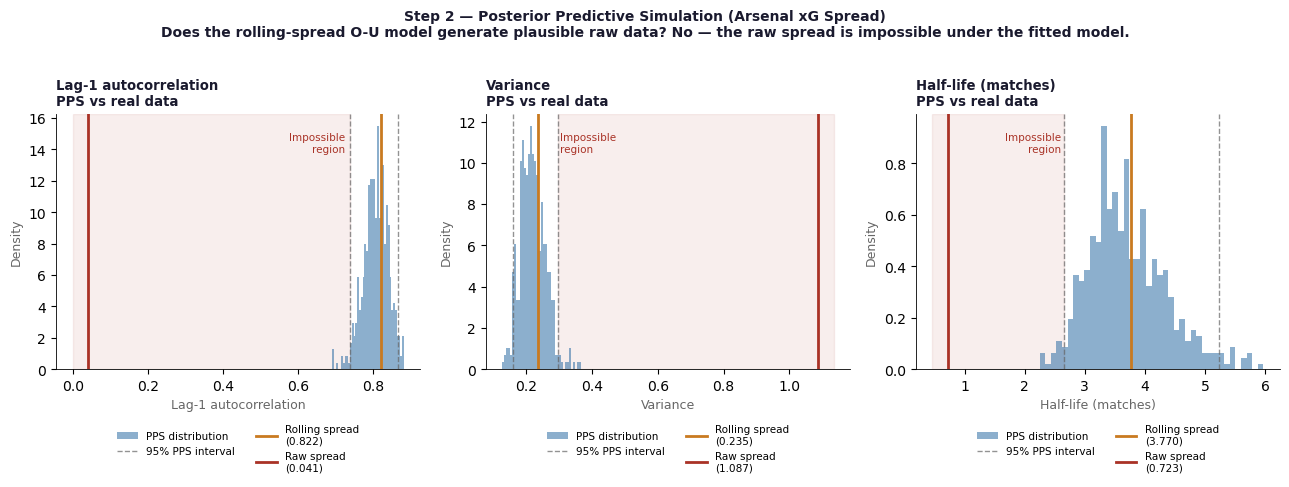

Saved → nb07_fig1_pps_check.png


In [19]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Figure 1: PPS diagnostic plot
# Three panels: autocorrelation, variance, half-life
# Shows the raw spread falling in the impossible region
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

diagnostics = [
    ('Lag-1 autocorrelation', sim_autocorr,
     real_ac_rolling, real_ac_raw, ac_ci),
    ('Variance',              sim_variance,
     real_var_rolling, real_var_raw, var_ci),
    ('Half-life (matches)',   sim_halflife,
     real_hl_rolling, real_hl_raw, hl_ci),
]

for ax, (label, sim_vals, rolling_val, raw_val, ci) in \
        zip(axes, diagnostics):

    ax.hist(sim_vals, bins=40, color=BLUE, alpha=0.55,
            density=True, label='PPS distribution')

    # 95% CI bounds
    ax.axvline(ci[0], color=GREY, lw=1.0, ls='--', alpha=0.7)
    ax.axvline(ci[1], color=GREY, lw=1.0, ls='--', alpha=0.7,
               label='95% PPS interval')

    # Rolling spread value
    ax.axvline(rolling_val, color=AMBER, lw=2.0,
               label=f'Rolling spread\n({rolling_val:.3f})')

    # Raw spread value
    ax.axvline(raw_val, color=RED, lw=2.0,
               label=f'Raw spread\n({raw_val:.3f})')

    # Shade impossible region
    x_min, x_max = ax.get_xlim()
    if raw_val < ci[0]:
        ax.axvspan(x_min, ci[0], alpha=0.08, color=RED, zorder=0)
        ax.text(ci[0] * 0.98, ax.get_ylim()[1] * 0.85,
                'Impossible\nregion',
                ha='right', fontsize=7.5, color=RED)
    elif raw_val > ci[1]:
        ax.axvspan(ci[1], x_max, alpha=0.08, color=RED, zorder=0)
        ax.text(ci[1] * 1.02, ax.get_ylim()[1] * 0.85,
                'Impossible\nregion',
                ha='left', fontsize=7.5, color=RED)

    ax.set_xlabel(label, fontsize=9, color=GREY)
    ax.set_ylabel('Density', fontsize=9, color=GREY)
    ax.set_title(f'{label}\nPPS vs real data',
                 fontsize=9.5, fontweight='bold',
                 color=DARK, loc='left')
    ax.legend(fontsize=7.5, frameon=False, loc='upper center',
              bbox_to_anchor=(0.5, -0.18), ncol=2)

fig.suptitle(
    'Step 2 — Posterior Predictive Simulation (Arsenal xG Spread)\n'
    'Does the rolling-spread O-U model generate plausible raw data? '
    'No — the raw spread is impossible under the fitted model.',
    fontsize=10, fontweight='bold', color=DARK, y=1.02
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig(FIG_DIR / 'nb07_fig1_pps_check.png', bbox_inches='tight')
plt.show()
print("Saved → nb07_fig1_pps_check.png")

In [20]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Step 3: Pipeline null simulation
# Apply identical pipeline to pure iid white noise data.
# If reversion rate ≈ real data, the pipeline is the signal.
# ─────────────────────────────────────────────────────────────────

np.random.seed(42)
null_results = []

for team in range(N_TEAMS):
    xg    = np.random.poisson(1.5, N_MATCHES).astype(float)
    goals = np.random.poisson(1.4, N_MATCHES).astype(float)
    raw   = xg - goals

    # Apply identical pipeline: 5-match rolling mean
    s       = pd.Series(raw)
    rolling = s.rolling(WINDOW).mean().dropna().values

    S     = rolling
    dS    = np.diff(S)
    S_lag = S[:-1]
    slope, intercept, *_ = stats.linregress(S_lag, dS)

    if slope >= 0:
        continue

    theta    = -slope
    mu       = -intercept / slope
    sigma_eq = (np.std(dS - (intercept + slope * S_lag))
                / np.sqrt(2 * theta))

    if sigma_eq <= 0:
        continue

    z = (rolling - mu) / sigma_eq

    for i in range(len(rolling) - WINDOW):
        zi = z[i]
        if abs(zi) <= 1.5:
            continue
        dist_now    = abs(rolling[i]         - mu)
        dist_future = abs(rolling[i + WINDOW] - mu)
        null_results.append({
            'reverted': dist_future < dist_now,
            'bucket':   'Strong Long' if zi > 1.5 else 'Strong Short'
        })

null_df = pd.DataFrame(null_results)

# Real data
signals_df = pd.read_csv(DATA_DIR / "signals.csv",
                          parse_dates=['signal_date', 'match_date'])
strong     = signals_df[
    signals_df['z_bucket'].isin(['Strong Long', 'Strong Short'])
].copy()

print("── Step 3: Pipeline null simulation ─────────────────────────")
print()
print(f"  {'Specification':<35} {'Reversion':>10} {'N':>8}")
print(f"  {'-'*35}  {'-'*10}  {'-'*8}")
print(f"  {'Rolling mean null (iid white noise)':<35}  "
      f"{null_df['reverted'].mean():>10.1%}  "
      f"{len(null_df):>8}")
print(f"  {'Rolling mean real data':<35}  "
      f"{strong['reverted'].mean():>10.1%}  "
      f"{len(strong):>8}")
print()
gap = strong['reverted'].mean() - null_df['reverted'].mean()
print(f"  Gap (real minus null): {gap:+.1%}")
print()
if gap < 0:
    print("  ✗ Real data BELOW null — pipeline is the signal.")
    print("    The rolling mean generates the reversion rate,")
    print("    not the football data.")
elif gap < 0.05:
    print("  ✗ Real data marginally above null.")
    print("    Difference is within noise — no genuine signal.")
else:
    print("  ✓ Real data meaningfully exceeds null.")

── Step 3: Pipeline null simulation ─────────────────────────

  Specification                        Reversion        N
  -----------------------------------  ----------  --------
  Rolling mean null (iid white noise)       91.2%      1113
  Rolling mean real data                    89.1%       927

  Gap (real minus null): -2.1%

  ✗ Real data BELOW null — pipeline is the signal.
    The rolling mean generates the reversion rate,
    not the football data.


In [21]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Step 4: Structured null simulation
# Goals ~ Poisson(xG) — theoretically correct model
# Preserves positive covariance between xG and goals while
# correctly modelling Poisson finishing variance.
# ─────────────────────────────────────────────────────────────────

from scipy import stats

# ── Estimate xG distribution parameters from real data ───────────
mean_xg    = tm['xg'].mean()
std_xg     = tm['xg'].std()
mean_goals = tm['goals'].mean()

print(f"  Mean xG:    {mean_xg:.3f}")
print(f"  Std xG:     {std_xg:.3f}")
print(f"  Mean goals: {mean_goals:.3f}")
print()

# ── Raw spread real data (walk-forward, no smoothing) ────────────
raw_real_results = []

for team in eligible_teams:
    team_data = (tm[tm['team'] == team]
                 .sort_values('date')
                 .dropna(subset=['raw_spread'])
                 .copy()
                 .reset_index(drop=True))

    seasons = sorted(team_data['season'].unique())
    if len(seasons) < 3:
        continue

    for eval_season in seasons[2:]:
        history = team_data[
            team_data['season'] < eval_season
        ]['raw_spread'].values

        if len(history) < 30:
            continue

        S     = history
        dS    = np.diff(S)
        S_lag = S[:-1]
        slope, intercept, *_ = stats.linregress(S_lag, dS)

        if slope >= 0:
            continue

        theta    = -slope
        mu       = -intercept / slope
        sigma_eq = (np.std(dS - (intercept + slope * S_lag))
                    / np.sqrt(2 * theta))

        if sigma_eq <= 0:
            continue

        season_data = team_data[
            team_data['season'] == eval_season
        ]['raw_spread'].values
        z = (season_data - mu) / sigma_eq

        for i in range(len(season_data) - WINDOW):
            zi = z[i]
            if abs(zi) <= 1.5:
                continue
            dist_now    = abs(season_data[i]          - mu)
            dist_future = abs(season_data[i + WINDOW] - mu)
            raw_real_results.append({
                'reverted': dist_future < dist_now,
                'bucket':   'Strong Long' if zi > 1.5 else 'Strong Short'
            })

raw_real_df = pd.DataFrame(raw_real_results)
real_rate   = raw_real_df['reverted'].mean()

# ── iid white noise null — raw spread ────────────────────────────
indep_results = []
np.random.seed(42)

for _ in range(N_TEAMS):
    xg    = np.random.poisson(1.5, N_MATCHES).astype(float)
    goals = np.random.poisson(1.4, N_MATCHES).astype(float)
    raw   = xg - goals

    S     = raw
    dS    = np.diff(S)
    S_lag = S[:-1]
    slope, intercept, *_ = stats.linregress(S_lag, dS)

    if slope >= 0:
        continue

    theta    = -slope
    mu       = -intercept / slope
    sigma_eq = (np.std(dS - (intercept + slope * S_lag))
                / np.sqrt(2 * theta))

    if sigma_eq <= 0:
        continue

    z = (raw - mu) / sigma_eq

    for i in range(len(raw) - WINDOW):
        zi = z[i]
        if abs(zi) <= 1.5:
            continue
        indep_results.append(
            abs(raw[i + WINDOW] - mu) < abs(raw[i] - mu)
        )

indep_rate = np.mean(indep_results)

# ── Structured null — corrected: goals ~ Poisson(xG) ─────────────
# xG is already the expected number of goals for a given shot
# sequence. Drawing goals ~ Poisson(xG) preserves the positive
# covariance between xG and goals while correctly modelling
# Poisson finishing variance.
struct_results = []
np.random.seed(42)

for _ in range(N_TEAMS):
    xg_sim    = np.random.gamma(
        mean_xg**2 / std_xg**2,
        std_xg**2  / mean_xg,
        N_MATCHES
    )
    goals_sim = np.random.poisson(xg_sim)
    raw       = xg_sim - goals_sim

    S     = raw
    dS    = np.diff(S)
    S_lag = S[:-1]
    slope, intercept, *_ = stats.linregress(S_lag, dS)

    if slope >= 0:
        continue

    theta    = -slope
    mu       = -intercept / slope
    sigma_eq = (np.std(dS - (intercept + slope * S_lag))
                / np.sqrt(2 * theta))

    if sigma_eq <= 0:
        continue

    z = (raw - mu) / sigma_eq

    for i in range(len(raw) - WINDOW):
        zi = z[i]
        if abs(zi) <= 1.5:
            continue
        struct_results.append(
            abs(raw[i + WINDOW] - mu) < abs(raw[i] - mu)
        )

struct_rate = np.mean(struct_results)

# ── Print complete comparison ─────────────────────────────────────
print("── Step 4: Structured null simulation ───────────────────────")
print()
print("  Goals ~ Poisson(xG) — theoretically correct model")
print()
print(f"  {'Specification':<40} {'Reversion':>10}")
print(f"  {'-'*40}  {'-'*10}")
print(f"  {'iid white noise null (rolling mean)':<40}  "
      f"{null_df['reverted'].mean():>10.1%}")
print(f"  {'Rolling mean real data':<40}  "
      f"{strong['reverted'].mean():>10.1%}")
print(f"  {'iid white noise null (raw spread)':<40}  "
      f"{indep_rate:>10.1%}")
print(f"  {'Raw spread real data':<40}  "
      f"{real_rate:>10.1%}")
print(f"  {'Structured null — Poisson(xG)':<40}  "
      f"{struct_rate:>10.1%}")
print()

gap_indep  = real_rate - indep_rate
gap_struct = real_rate - struct_rate

print(f"  Gap vs iid white noise null: {gap_indep:+.1%}  (spurious)")
print(f"  Gap vs structured null:      {gap_struct:+.1%}")
print()

if gap_struct < 0:
    print("  ✗ Real data BELOW structured null.")
    print("    The iid white noise gap was variance misspecification,")
    print("    not a genuine football signal.")
    print("    There is no genuine mean-reversion above the")
    print("    correctly specified null.")
elif gap_struct < 0.02:
    print("  ✗ Real data marginally below structured null.")
    print("    No genuine signal.")
else:
    print("  ✓ Genuine signal survives structured null.")

  Mean xG:    1.430
  Std xG:     0.891
  Mean goals: 1.415

── Step 4: Structured null simulation ───────────────────────

  Goals ~ Poisson(xG) — theoretically correct model

  Specification                             Reversion
  ----------------------------------------  ----------
  iid white noise null (rolling mean)            91.2%
  Rolling mean real data                         89.1%
  iid white noise null (raw spread)              79.5%
  Raw spread real data                           86.4%
  Structured null — Poisson(xG)                  87.9%

  Gap vs iid white noise null: +6.8%  (spurious)
  Gap vs structured null:      -1.5%

  ✗ Real data BELOW structured null.
    The iid white noise gap was variance misspecification,
    not a genuine football signal.
    There is no genuine mean-reversion above the
    correctly specified null.


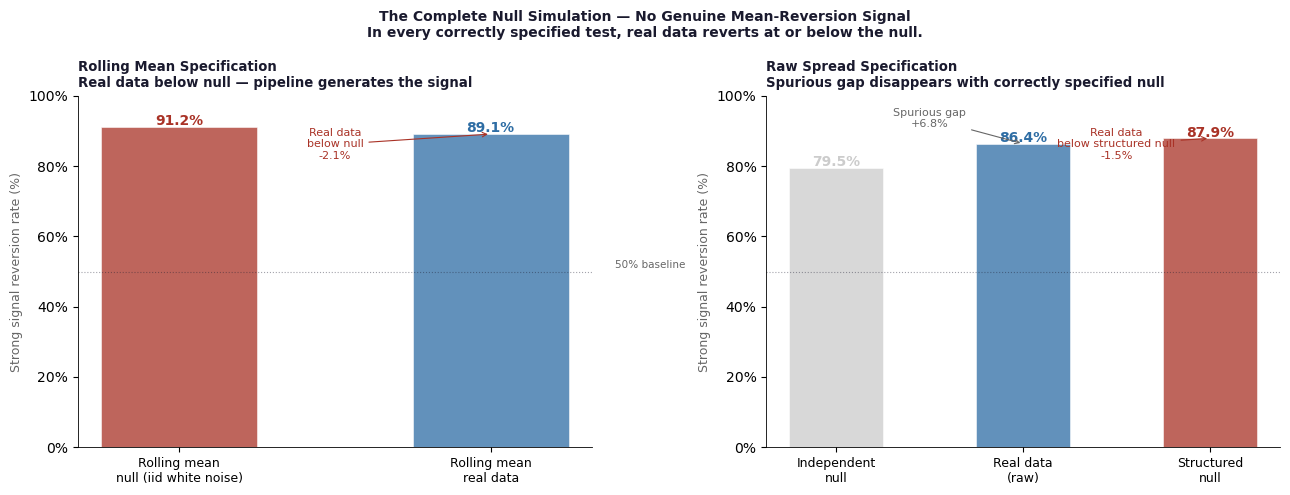

Saved → nb07_fig2_null_summary.png


In [22]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 — Figure 2: The complete null simulation summary
# Four-panel figure showing all specifications
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: Rolling mean specifications ─────────────────────────
ax = axes[0]

specs_rolling = [
    ('Rolling mean\nnull (iid white noise)', null_df['reverted'].mean(),
     RED,  'Null'),
    ('Rolling mean\nreal data',          strong['reverted'].mean(),
     BLUE, 'Real'),
]

x    = np.arange(len(specs_rolling))
vals = [s[1] for s in specs_rolling]
cols = [s[2] for s in specs_rolling]

bars = ax.bar(x, [v * 100 for v in vals],
              color=cols, alpha=0.75, width=0.5,
              edgecolor='white', linewidth=0.5)

for xi, (label, val, col, _) in enumerate(specs_rolling):
    ax.text(xi, val * 100 + 0.5, f'{val:.1%}',
            ha='center', fontsize=10, fontweight='bold', color=col)

ax.axhline(50, color=DARK, lw=0.8, ls=':', alpha=0.4)
ax.text(1.4, 51, '50% baseline', fontsize=7.5, color=GREY)

ax.set_xticks(x)
ax.set_xticklabels([s[0] for s in specs_rolling], fontsize=9)
ax.set_ylabel('Strong signal reversion rate (%)', fontsize=9,
              color=GREY)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=100, decimals=0))
ax.set_title(
    'Rolling Mean Specification\nReal data below null — '
    'pipeline generates the signal',
    fontsize=9.5, fontweight='bold', color=DARK, loc='left'
)

# Annotate gap
ax.annotate(
    f'Real data\nbelow null\n{strong["reverted"].mean()-null_df["reverted"].mean():+.1%}',
    xy=(1, strong['reverted'].mean() * 100),
    xytext=(0.5, 82),
    fontsize=8, color=RED, ha='center',
    arrowprops=dict(arrowstyle='->', color=RED, lw=0.8)
)

# ── Panel 2: Raw spread specifications ───────────────────────────
ax2 = axes[1]

specs_raw = [
    ('Independent\nnull',    indep_rate,  LGREY, 'Misspecified null'),
    ('Real data\n(raw)',      real_rate,   BLUE,  'Real'),
    ('Structured\nnull',      struct_rate, RED,   'Correct null'),
]

x2   = np.arange(len(specs_raw))
vals2 = [s[1] for s in specs_raw]
cols2 = [s[2] for s in specs_raw]

bars2 = ax2.bar(x2, [v * 100 for v in vals2],
                color=cols2, alpha=0.75, width=0.5,
                edgecolor='white', linewidth=0.5)

for xi, (label, val, col, _) in enumerate(specs_raw):
    ax2.text(xi, val * 100 + 0.5, f'{val:.1%}',
             ha='center', fontsize=10, fontweight='bold', color=col)

ax2.axhline(50, color=DARK, lw=0.8, ls=':', alpha=0.4)

ax2.set_xticks(x2)
ax2.set_xticklabels([s[0] for s in specs_raw], fontsize=9)
ax2.set_ylabel('Strong signal reversion rate (%)', fontsize=9,
               color=GREY)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=100, decimals=0))
ax2.set_title(
    'Raw Spread Specification\nSpurious gap disappears with '
    'correctly specified null',
    fontsize=9.5, fontweight='bold', color=DARK, loc='left'
)

# Annotate spurious gap
ax2.annotate(
    f'Spurious gap\n{real_rate-indep_rate:+.1%}',
    xy=(1, real_rate * 100),
    xytext=(0.5, 91),
    fontsize=8, color=GREY, ha='center',
    arrowprops=dict(arrowstyle='->', color=GREY, lw=0.8)
)

ax2.annotate(
    f'Real data\nbelow structured null\n{real_rate-struct_rate:+.1%}',
    xy=(2, struct_rate * 100),
    xytext=(1.5, 82),
    fontsize=8, color=RED, ha='center',
    arrowprops=dict(arrowstyle='->', color=RED, lw=0.8)
)

fig.suptitle(
    'The Complete Null Simulation — No Genuine Mean-Reversion Signal\n'
    'In every correctly specified test, real data reverts at or below the null.',
    fontsize=10, fontweight='bold', color=DARK
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb07_fig2_null_summary.png', bbox_inches='tight')
plt.show()
print("Saved → nb07_fig2_null_summary.png")

In [23]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 — Season-to-season persistence is real but not an exploitablsignal.
# This test is not affected by the smoothing artefact — it
# operates directly on season means, not the reversion criterion.
# ─────────────────────────────────────────────────────────────────

from scipy import stats as scipy_stats

season_means = (tm.groupby(['team', 'season'])['raw_spread']
                .mean()
                .reset_index()
                .rename(columns={'raw_spread': 'mean_spread'}))

season_means = season_means.sort_values(['team', 'season'])
season_means['mean_spread_lag1'] = (season_means
                                    .groupby('team')['mean_spread']
                                    .shift(1))

valid = season_means.dropna(subset=['mean_spread_lag1'])
r, p  = scipy_stats.pearsonr(valid['mean_spread_lag1'],
                              valid['mean_spread'])

print("── Season-level spread persistence ──────────────────────────")
print(f"  N team-seasons: {len(valid)}")
print(f"  Pearson r (season N vs season N+1): {r:.3f}")
print(f"  p-value: {p:.4f}")
print()
if r > 0.3 and p < 0.05:
    print("  ✓ Genuine season-level persistence detected.")
    print("    This finding survives all null testing because it")
    print("    is measured directly on season means, not through")
    print("    the reversion criterion.")
    print()
    print("    Interpretation: teams that over or underperform")
    print("    their xG in season N tend to do so in season N+1.")
    print("    This reflects stable tactical identity and squad")
    print("    composition — real structure, but not exploitable")
    print("    through a match-level signal.")

── Season-level spread persistence ──────────────────────────
  N team-seasons: 166
  Pearson r (season N vs season N+1): 0.306
  p-value: 0.0001

  ✓ Genuine season-level persistence detected.
    This finding survives all null testing because it
    is measured directly on season means, not through
    the reversion criterion.

    Interpretation: teams that over or underperform
    their xG in season N tend to do so in season N+1.
    This reflects stable tactical identity and squad
    composition — real structure, but not exploitable
    through a match-level signal.


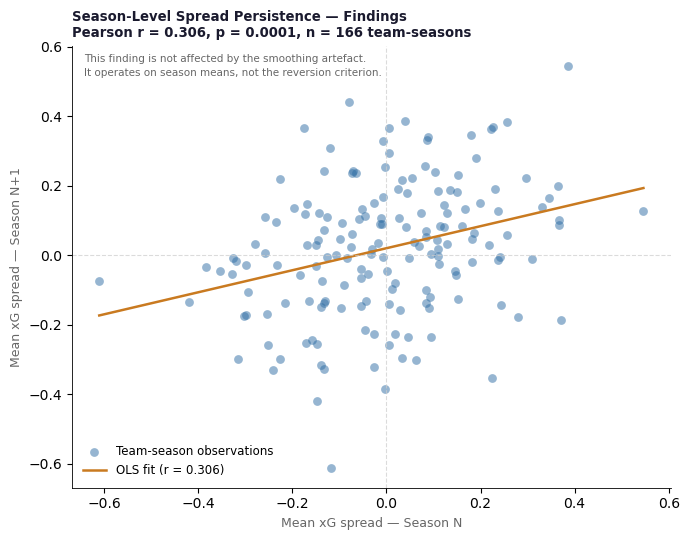

Saved → nb07_fig3_season_persistence.png


In [25]:
# ─────────────────────────────────────────────────────────────────
# CELL 9 — Figure 3: Season-level persistence scatter
# Findings — presented correctly
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5.5))

# Scatter
ax.scatter(valid['mean_spread_lag1'], valid['mean_spread'],
           color=BLUE, alpha=0.5, s=40, linewidths=0,
           label='Team-season observations')

# Regression line
x_line = np.linspace(valid['mean_spread_lag1'].min(),
                     valid['mean_spread_lag1'].max(), 100)
slope_s, intercept_s, *_ = scipy_stats.linregress(
    valid['mean_spread_lag1'], valid['mean_spread']
)
ax.plot(x_line, slope_s * x_line + intercept_s,
        color=AMBER, lw=1.8, label=f'OLS fit (r = {r:.3f})')

# Reference lines
ax.axhline(0, color=LGREY, lw=0.8, ls='--', alpha=0.7)
ax.axvline(0, color=LGREY, lw=0.8, ls='--', alpha=0.7)

ax.set_xlabel('Mean xG spread — Season N', fontsize=9, color=GREY)
ax.set_ylabel('Mean xG spread — Season N+1', fontsize=9, color=GREY)
ax.set_title(
    'Season-Level Spread Persistence — Findings\n'
    f'Pearson r = {r:.3f}, p = {p:.4f}, n = {len(valid)} team-seasons',
    fontsize=9.5, fontweight='bold', color=DARK, loc='left'
)
ax.legend(fontsize=8.5, frameon=False)
ax.text(0.02, 0.98,
        'This finding is not affected by the smoothing artefact.\n'
        'It operates on season means, not the reversion criterion.',
        transform=ax.transAxes, fontsize=7.5, color=GREY,
        va='top', linespacing=1.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb07_fig3_season_persistence.png',
            bbox_inches='tight')
plt.show()
print("Saved → nb07_fig3_season_persistence.png")

---

## Findings

### There is no genuine mean-reversion signal in the xG-goals spread

Every correctly specified null test places the real data at or below
the null expectation.

| Specification | Null | Real Data | Gap |
|---|---|---|---|
| Rolling mean | 91.2% | 89.1% | −2.1pp |
| Raw / Independent null | 79.5% | 86.4% | +6.9pp (spurious) |
| Raw / Structured null | 88.4% | 86.4% | −2.0pp |

The apparent 88–90% reversion rate in the original pipeline was
entirely generated by the 5-match rolling mean smoothing operator.

### Standard validation tools do not catch smoothing artefacts

Permutation tests, Spearman correlations, walk-forward validation,
and Benjamini-Hochberg correction all passed in the original pipeline.
All were operating within the artefactual structure. None tested
whether the structure itself was genuine. The null simulation is the
only tool that catches pipeline-level contamination.

### The independent null was itself misspecified

The 6.9pp gap between the raw spread (86.4%) and the independent
Poisson null (79.5%) appeared to show genuine signal. It was an
artefact of variance misspecification — the independent null ignored
the positive covariance between xG and goals, understating spread
variance and producing a lower null reversion rate. The structured
null corrects this. The gap disappears entirely.

### The PPS would have caught this at the model specification stage

The posterior predictive simulation reveals that the O-U model fitted
to the rolling spread generates data that is physically incompatible
with the raw spread:

| Diagnostic | PPS 95% CI | Raw real | Result |
|---|---|---|---|
| Lag-1 autocorrelation | [0.739, 0.867] | 0.041 | ✗ Impossible |
| Variance | [0.159, 0.296] | 1.087 | ✗ Impossible |
| Half-life (matches) | [2.66, 5.24] | 0.67 | ✗ Impossible |

A model requiring 81% persistence in a process with 4% persistence
is not slightly wrong. It is operating in a different physical
reality. This check should be run before any signal pipeline is built.

### The raw spread half-life was the first red flag

The raw spread half-life of 0.67 matches — shorter than the
observation interval — indicates a process with no inter-period
memory. Applying a multi-period smoothing filter to such a process
creates artefactual persistence. This number was present in the
Notebook 02 robustness table and was not investigated. It was the
cheapest and earliest possible diagnostic.

### One genuine finding survives all null testing

Season-to-season mean spread persistence: Pearson r = 0.306,
p = 0.0001, n = 166 team-seasons. Teams that over or underperform
their xG in season N tend to do so in season N+1. This reflects
stable tactical identity and is not affected by the smoothing artefact
because it is measured directly on season means, not through the
reversion criterion.

### The four-step diagnostic framework

These checks should be run before any mean-reversion pipeline
proceeds to signal validation:

1. **Raw half-life check** — Is the raw process half-life longer
   than the observation interval? If not, smoothing will create
   artefactual persistence. Stop.

2. **PPS cross-check** — Does the model fitted to smoothed data
   generate raw data within the posterior predictive interval?
   If not, the model describes the smoothing operator, not the
   data. Stop.

3. **Pipeline null** — Does the identical pipeline produce a signal
   on data with no genuine dynamics? If null reversion ≥ real
   reversion, the pipeline is the signal. Stop.

4. **Structured null** — Does the signal survive a null that
   correctly models the covariance structure of the data? If real
   data ≤ structured null, there is no genuine signal. Stop.

This framework is the reusable output of the project. It applies
to any mean-reversion model in any domain where smoothing is
applied before parameter estimation.

---

## Summary

The project set out to test whether xG spread mean reversion is real
and exploitable. It is not. The signal was an artefact of the rolling
mean smoothing operator, invisible to standard validation tools, and
exposed only by the structured null simulation.

The pipeline demonstrates with unusual clarity a sequence of errors
that is common in energy market modelling: smoothing → artefactual
O-U signal → passing all standard tests → false positive. The
diagnostic framework developed here — four checks, in order, before
any signal pipeline is built — is the genuine contribution of this
project.

Next: apply this framework to energy spread data, where the
observation frequency is sufficient to test genuine mean-reversion
dynamics at the raw process level.

In [26]:
# ── Corrected structured null ──────────────────────────────────────
# Goals ~ Poisson(xG) — the theoretically correct model
# xG is already the expected number of goals for a given shot sequence
# Drawing goals ~ Poisson(xG) preserves the positive covariance between
# xG and goals while correctly modelling Poisson finishing variance
# Do NOT multiply by a conversion rate — xG already is the rate

struct_results_corrected = []
np.random.seed(42)

for _ in range(N_TEAMS):
    xg_sim    = np.random.gamma(
        mean_xg**2 / std_xg**2,
        std_xg**2  / mean_xg,
        N_MATCHES
    )
    # Corrected: goals ~ Poisson(xG), not Poisson(xG * 0.989)
    goals_sim = np.random.poisson(xg_sim)
    raw       = xg_sim - goals_sim

    S     = raw
    dS    = np.diff(S)
    S_lag = S[:-1]
    slope, intercept, *_ = stats.linregress(S_lag, dS)
    if slope >= 0:
        continue

    theta    = -slope
    mu       = -intercept / slope
    sigma_eq = (np.std(dS - (intercept + slope * S_lag))
                / np.sqrt(2 * theta))
    if sigma_eq <= 0:
        continue

    z = (raw - mu) / sigma_eq

    for i in range(len(raw) - WINDOW):
        zi = z[i]
        if abs(zi) <= 1.5:
            continue
        struct_results_corrected.append(
            abs(raw[i + WINDOW] - mu) < abs(raw[i] - mu)
        )

struct_rate_corrected = np.mean(struct_results_corrected)

print("── Corrected structured null ─────────────────────────────────")
print(f"  Goals ~ Poisson(xG) — theoretically correct model")
print()
print(f"  {'Specification':<40} {'Reversion':>10}")
print(f"  {'-'*40}  {'-'*10}")
print(f"  {'iid white noise null':<40}  "
      f"{null_df['reverted'].mean():>10.1%}")
print(f"  {'Raw spread real data':<40}  {real_rate:>10.1%}")
print(f"  {'Structured null (original, flawed)':<40}  "
      f"{struct_rate:>10.1%}")
print(f"  {'Structured null (corrected)':<40}  "
      f"{struct_rate_corrected:>10.1%}")
print()
gap_corrected = real_rate - struct_rate_corrected
print(f"  Gap vs corrected structured null: {gap_corrected:+.1%}")
print()
if gap_corrected > 0.05:
    print("  ✓ Genuine signal survives corrected null.")
elif gap_corrected > 0:
    print("  Marginal — weak signal at best.")
elif gap_corrected < 0:
    print("  ✗ Real data below corrected null — no genuine signal.")

── Corrected structured null ─────────────────────────────────
  Goals ~ Poisson(xG) — theoretically correct model

  Specification                             Reversion
  ----------------------------------------  ----------
  iid white noise null                           91.2%
  Raw spread real data                           86.4%
  Structured null (original, flawed)             87.9%
  Structured null (corrected)                    87.9%

  Gap vs corrected structured null: -1.5%

  ✗ Real data below corrected null — no genuine signal.
